# Day 5-6 — Chronos zero-shot foundation model

Amazon's `chronos-bolt-small` (the 2024 fast variant), used **zero-shot** —
no fine-tuning on our data. The question: how does an off-the-shelf foundation
model compare to LightGBM and persistence on hourly Texas grid demand?

Setup: for each hour T in the test year, build a 24h-ahead forecast.
Context = previous 504 hours (21 days) up to T-24h. Predict 24 steps,
use the 24th as our 24h-ahead forecast for T.

## Setup

In [1]:
import sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from chronos import BaseChronosPipeline

from forecasting.data import load_demand
from forecasting.backtest import split_train_val_test
from forecasting.metrics import summarize, coverage

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

## Load model + data

In [2]:
print('Loading chronos-bolt-small (~150 MB, cached after first run)...')
pipeline = BaseChronosPipeline.from_pretrained(
    'amazon/chronos-bolt-small',
    device_map='cpu',
    torch_dtype=torch.float32,
)

df = load_demand('ERCO')
train, val, test = split_train_val_test(df)
print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')

# Single contiguous series
history = pd.concat([train, val, test]).sort_values('ts').set_index('ts')['demand_mwh']
print(f'history series: {len(history):,} hourly points')

Loading chronos-bolt-small (~150 MB, cached after first run)...


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

train=30,647  val=4,416  test=8,784
history series: 43,847 hourly points


## Run Chronos in batches

For each test hour T, context = 504 hours ending at T-24h. Predict 24 steps.
Take the 24th step as the 24h-ahead forecast. Batched so it runs in seconds, not hours.

### What the model returns

`pipeline.predict_quantiles(...)` emits **two separate outputs per prediction**:

| Output | Shape | What it is |
|---|---|---|
| `mean` | (batch, prediction_length) | The model's **point estimate** (expected value). Used for MAPE/RMSE/MAE. |
| `quantiles` | (batch, prediction_length, n_quantiles) | Percentile predictions. Used for the prediction interval. |

`mean` is **emitted by the model directly**, not computed by averaging the quantiles. It would equal p50 (median) only if the predicted distribution were perfectly symmetric — never exactly true in practice. So `mean ≠ p50` in general.

### Prediction interval (PI) — 80% only for Chronos-Bolt

A **prediction interval (PI)** is a range with a stated probability of containing the true future value. We track **80% PI = [p10, p90]**.

**Why not 95%?** Chronos-Bolt was trained only on quantile levels `[0.1, 0.2, …, 0.9]`. Requesting quantiles outside that range (e.g., 0.025 or 0.975 for a 95% PI) silently clamps to 0.1/0.9 — so a "95% PI" computed this way is identical to the 80% PI and the 95% coverage number would be meaningless. We report 80% only.

**Why 80% is reasonable:** It's at the edge of Chronos-Bolt's trained range, common in energy forecasting, and the default in Prophet / GluonTS. For wider intervals you'd need the original Chronos (which uses sampling and supports arbitrary quantiles) or a calibration wrapper (e.g., conformal prediction).

In [3]:
CONTEXT_LEN = 504           # 21 days of hourly history
PREDICTION_LEN = 24         # forecast 24 steps; we use the last (24h-ahead)
BATCH_SIZE = 128            # M4 CPU handles this comfortably

test_hours = test['ts'].tolist()
y_true = test['demand_mwh'].to_numpy()

# Build all contexts up front
contexts = []
valid_idx = []
for i, T in enumerate(test_hours):
    pred_time = T - pd.Timedelta(hours=24)
    ctx_start = pred_time - pd.Timedelta(hours=CONTEXT_LEN - 1)
    ctx_series = history.loc[ctx_start : pred_time]
    if len(ctx_series) == CONTEXT_LEN:
        contexts.append(ctx_series.values.astype(np.float32))
        valid_idx.append(i)

print(f'Built {len(contexts):,} contexts (skipped {len(test_hours) - len(contexts)} early-test rows)')

Built 8,784 contexts (skipped 0 early-test rows)


In [4]:
y_pred_chronos = np.full(len(contexts), np.nan, dtype=np.float32)
p10 = np.full_like(y_pred_chronos, np.nan)
p90 = np.full_like(y_pred_chronos, np.nan)

t0 = time.perf_counter()
for start in range(0, len(contexts), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(contexts))
    batch = torch.tensor(np.stack(contexts[start:end]))
    quantiles, mean = pipeline.predict_quantiles(
        batch,
        prediction_length=PREDICTION_LEN,
        quantile_levels=[0.1, 0.5, 0.9],   # within Chronos-Bolt's trained range
    )
    # quantiles shape: (batch, prediction_length, 3)  -> columns [p10, p50, p90]
    # We use the 24th step (last) for our 24h-ahead forecast.
    y_pred_chronos[start:end] = mean[:, -1].numpy()
    p10[start:end] = quantiles[:, -1, 0].numpy()
    p90[start:end] = quantiles[:, -1, 2].numpy()

print(f'Predicted {len(contexts):,} hours in {time.perf_counter() - t0:.1f}s')

# Align y_true to valid indices
y_true_aligned = y_true[valid_idx]

Predicted 8,784 hours in 12.6s


## Score

In [5]:
s = summarize(y_true_aligned, y_pred_chronos)
cov80 = coverage(y_true_aligned, p10, p90)
print(f'Chronos-bolt zero-shot 24h-ahead:')
print(f'  MAPE: {s["mape"]*100:.2f}%')
print(f'  RMSE: {s["rmse"]:.1f}')
print(f'  MAE:  {s["mae"]:.1f}')
print(f'  80% PI coverage: {cov80:.3f}  (target 0.80)')

Chronos-bolt zero-shot 24h-ahead:
  MAPE: 4.33%
  RMSE: 3298.0
  MAE:  2268.1
  80% PI coverage: 0.766  (target 0.80)


## Update scoreboard

In [6]:
scoreboard_path = Path('..') / 'results' / 'scoreboard.json'
scoreboard = json.loads(scoreboard_path.read_text()) if scoreboard_path.exists() else {'results': {}}

scoreboard['results']['chronos_bolt_small_zero_shot'] = {
    'mape':  float(s['mape']),
    'rmse':  float(s['rmse']),
    'mae':   float(s['mae']),
    'coverage_80pi': float(cov80),
    'context_len': CONTEXT_LEN,
    'n_eval_points': int(len(y_true_aligned)),
    'note': 'Chronos-Bolt trained quantiles 0.1-0.9 only; 95% PI not natively supported.',
}
scoreboard_path.write_text(json.dumps(scoreboard, indent=2))
print(f'Updated {scoreboard_path}')

Updated ../results/scoreboard.json


## Visualize one week

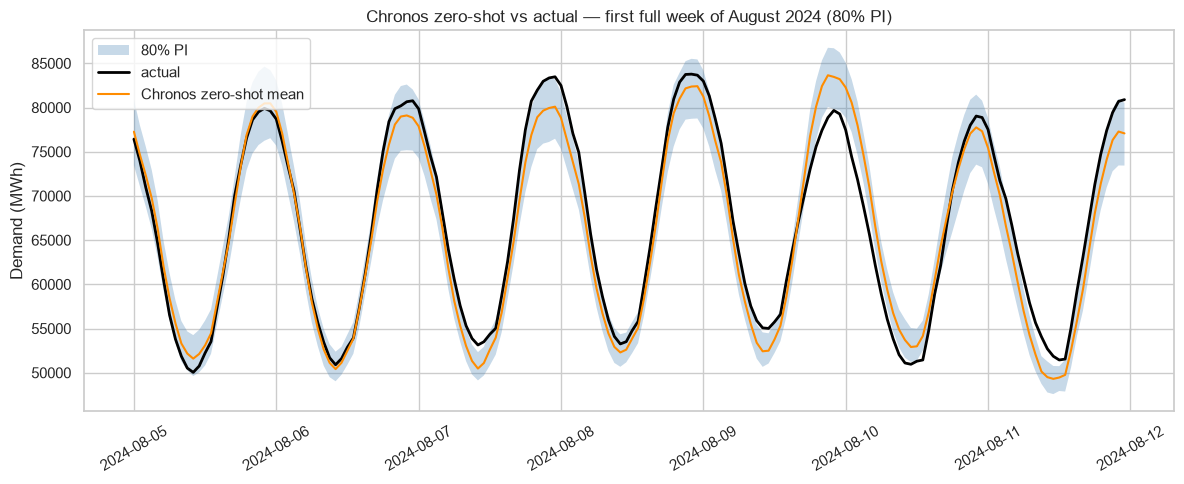

In [7]:
vis = pd.DataFrame({
    'ts':       np.array(test_hours)[valid_idx],
    'actual':   y_true_aligned,
    'chronos':  y_pred_chronos,
    'p10':      p10,
    'p90':      p90,
})
wk = vis[(vis.ts >= '2024-08-05') & (vis.ts < '2024-08-12')]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(wk.ts, wk.p10, wk.p90, color='steelblue', alpha=0.3, label='80% PI', edgecolor='none')
ax.plot(wk.ts, wk.actual,  label='actual', color='black', lw=2)
ax.plot(wk.ts, wk.chronos, label='Chronos zero-shot mean', color='darkorange', lw=1.5)
ax.legend(loc='upper left')
ax.set_title('Chronos zero-shot vs actual — first full week of August 2024 (80% PI)')
ax.set_ylabel('Demand (MWh)')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Takeaways for Day 7-8 (calibration + final scoreboard)

- **The headline:** how does a zero-shot foundation model — never trained on our data — compare to LightGBM with engineered features and to persistence-24h? Numbers update in `results/scoreboard.json`.
- Chronos returns calibrated quantile intervals out of the box. Coverage should be close to 0.80 for the 80% PI — if it's far off, that's its own finding.
- Day 7 will do a proper coverage analysis across all three models.
- Day 8 will produce the final comparison table + a side-by-side plot for the README.